In [34]:
# Some data-handling functions to download/import.

# from https://github.com/yandexdataschool/mlhep2018/blob/master/day2-Tue/seminar-03-keras-cnn/seminar_tf_keras.ipynb
"""I load some cifar"""

import numpy as np
from sklearn.model_selection import train_test_split
import os, sys
if sys.version_info[0] == 2:
    from urllib import urlretrieve
    import cPickle as pickle

else:
    from urllib.request import urlretrieve
    import pickle

def unpickle(file):
    fo = open(file, 'rb')
    if sys.version_info[0] == 2:
        dict = pickle.load(fo)
    else:
        dict = pickle.load(fo,encoding='latin1')
    
    fo.close()
    return dict




def download_cifar10(path,
                     url='https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz',
                     tarname='cifar-10-python.tar.gz',):
    import tarfile
    if not os.path.exists(path):
        os.mkdir(path)
    
        

    urlretrieve(url, os.path.join(path,tarname))
    tfile = tarfile.open(os.path.join(path,tarname))
    tfile.extractall(path=path)
    

def load_cifar10(data_path=".",channels_last=False,test_size=0.2,random_state=1337):
    
    test_path = os.path.join(data_path,"cifar-10-batches-py/test_batch")
    train_paths = [os.path.join(data_path,"cifar-10-batches-py/data_batch_%i"%i) for i in range(1,6)]
    
    if not os.path.exists(test_path) or not all(list(map(os.path.exists, train_paths))):
        print ("Dataset not found. Downloading...")
        download_cifar10(data_path)

    train_batches = list(map(unpickle,train_paths))
    test_batch = unpickle(test_path)

    X = np.concatenate([batch["data"] for batch in train_batches]).reshape([-1,3,32,32]).astype('float32')/255
    y = np.concatenate([batch["labels"] for batch in train_batches]).astype('int32')
    X_train,X_val,y_train,y_val = train_test_split(X,y,
                                                   test_size=test_size,
                                                   random_state=random_state)
    
    X_test = test_batch["data"].reshape([-1,3,32,32]).astype('float32')/255
    y_test = np.array(test_batch["labels"]).astype('int32')
    
    if channels_last:
        #convert from [batch,3,H,W] to [batch,H,W,3]
        #WARNING! Make this is only necessary for tensorflow-style dim order
        #If you use theano-style dimensions in keras config, skip this cell
        X_train = X_train.transpose([0,2,3,1])
        X_val   = X_val.transpose([0,2,3,1])
        X_test  = X_test.transpose([0,2,3,1])

    
    return X_train,y_train,X_val,y_val,X_test,y_test

 here, different function meant to help download the dataset. The dataset contains images of 10 different object categories. The functions download the dataset, extract the files, and load the image data and labels into NumPy arrays. The images are also normalized to values between 0 and 1 to make training the network easier.

In [35]:
import tensorflow as tf
#gpu_options = tf.GPUOptions(allow_growth=True, per_process_gpu_memory_fraction=0.1) # restricts GPU load for multi-user nodes

import tensorflow.keras as keras
from keras import backend as K
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
print(tf.__version__)
print(keras.__version__)

2.20.0
3.13.2


Here, we import the main libraries needed. TensorFlow and Keras are used to build and train network. NumPy is used for numerical operations, and Matplotlib is used for graphs and other vizualization tools. The cell also prints the installed versions of TensorFlow and Keras to confirm its all good.

In [36]:
# Load the data samples

x_train,y_train,x_val,y_val,x_test,y_test = load_cifar10("cifar_data",channels_last=True)

NUM_CLASSES = 10
cifar10_classes = ["airplane", "automobile", "bird", "cat", "deer", 
                   "dog", "frog", "horse", "ship", "truck"]

print("Train samples:", x_train.shape, y_train.shape)
print("Test samples:", x_test.shape, y_test.shape)
print("Val samples:", x_val.shape, y_val.shape)

Train samples: (40000, 32, 32, 3) (40000,)
Test samples: (10000, 32, 32, 3) (10000,)
Val samples: (10000, 32, 32, 3) (10000,)


Here, the dataset is loaded using the functions defined previously. The dataset is divided into three parts: a training set used to train the network, a validation set used to check on performance while training, and a test set to evaluate the final model. The cell also defines the names of the 10 classes and prints the shapes of the datasets to verify that the data was loaded properly.

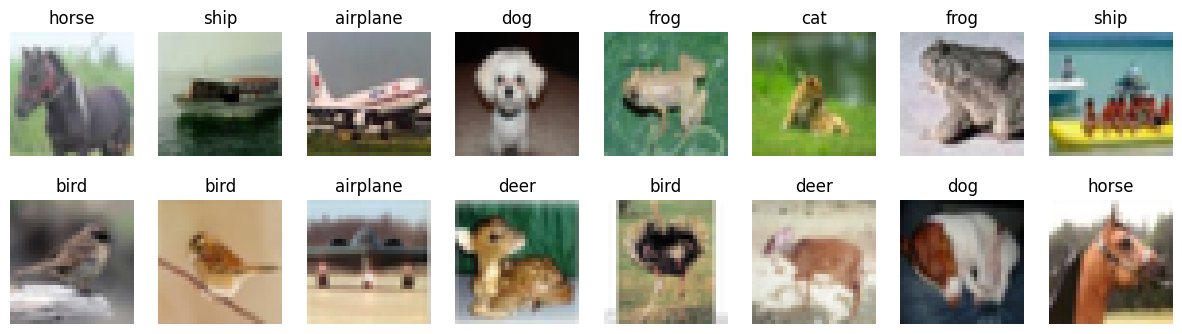

In [37]:
# show some random images from train, and their labels

cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 2.5 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_train))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_train[random_index, :])
        ax.set_title(cifar10_classes[y_train[random_index]])
plt.show()

Here, several random images are shown from the training dataset together with the right labels. This helps check that the dataset was loaded properly and allows a visual check of the types of images the model will learn from.

In [38]:
# normalize inputs
# convert class labels to one-hot encoded, should have shape (?, NUM_CLASSES)
# x_train = x_train.astype(np.float64) - 0.5

y_train = keras.utils.to_categorical(y_train, num_classes=10)

y_val = keras.utils.to_categorical(y_val, num_classes=10)

y_test = keras.utils.to_categorical(y_test, num_classes=10)

Here, the class labels are converted into one-hot encoded vectors. Instead of representing each class with a single number (0–9), the labels are converted into vectors of length 10 where the right class is represented by a 1 and the other positions are 0. 

In [39]:
# import necessary building blocks
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.layers import LeakyReLU
from keras.layers import BatchNormalization

Here, the line from keras.layers import BatchNormalization was added to import the BatchNormalization layer. This layer helps stabilize and speed up training by normalizing the outputs of a layer, it can also improve the accuracy.

In [40]:
def make_model():
    """
    Define your model architecture here.
    Returns `Sequential` model.
    """

    model = Sequential()

    ### STUDENT CODE HERE ###
    ### --> Build your convolutional neural network. 
    ### First, make a CNN layer with some small kernels to learn some basic features, with Conv2D.
    ### Then, add a Pooling layer to pick up the relevant kernels.
    ### Then, Flatten it and add some fully-connected (Dense) normal NN layers,
    ###  to learn the relevant combinations of low-level kernel features.
    ### Finally, some regularisation is advised, using a Dropout layer, to avoid local minima.
    ### Make sure the output is of the same shape as the number of labels we have,
    ### And the input is the same as the figures (which now have a 3rd dimension - color!)
    ### Again, use google to find information on these classes. 


     # First convolution block
    model.add(Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2D(32, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(MaxPooling2D(pool_size=(2,2)))

    # Second convolution block
    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(Conv2D(64, (3,3), padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU())

    model.add(MaxPooling2D(pool_size=(2,2)))

    # Flatten features
    model.add(Flatten())

    # Dense layer
    model.add(Dense(256))
    model.add(LeakyReLU())

    # Dropout to reduce overfitting
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(NUM_CLASSES))

    ### END STUDENT CODE ### 

    # Ensure normalized probabilities over the 10 classes
    model.add(Activation("softmax")) 

    return model

Here, the convolutional network architecture is defined. The model is made out of two convolutional blocks that extract visual features from the images.

Each block contains convolutional layers that apply small filters to the images to detect patterns like edges, textures, and shapes. Then, after each convolution layer, a batch normalization layer is used to normalize the activations, it helps stabilize and accelerate training. A LeakyReLU activation function then introduces non-linearity so that the network can learn more complex patterns.

Max pooling layers are used to reduce the size of the feature maps but still preserv the most important information. This helps reduce computation and prevents overfitting.

After the convolutional feature extraction, the feature maps are flattened into a one-dimensional vector. A denser layer then learns higher level combinations of the features that were extracted earlier. A dropout layer randomly disables some neurons during training to reduce overfitting.

Finally, the output layer produces predictions for the 10 classes, and a softmax activation function converts these predictions into normalized class probabilities.

In [41]:
### STUDENT CODE HERE ###
### --> change the parameters below to perform a better training

INIT_LR = 1e-3  # initial learning rate
BATCH_SIZE = 64
EPOCHS = 20

K.clear_session()  # clear default graph
# don't call K.set_learning_phase() !!! (otherwise will enable dropout in train/test simultaneously)
model = make_model()  # define our model

# prepare model for fitting (loss, optimizer, etc)
model.compile(
    loss='categorical_crossentropy',  # we train 10-way classification
    optimizer=keras.optimizers.Adamax(learning_rate=INIT_LR),  # for SGD.
    metrics=['accuracy']  # report accuracy during training
)


# fit model

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)

model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),  # prepared data
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val),
    shuffle=True,
)

# save weights to file to avoid re-training
model.save_weights("myweights.weights.h5")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.3841 - loss: 1.8470 - val_accuracy: 0.4661 - val_loss: 1.4998
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 52ms/step - accuracy: 0.4940 - loss: 1.4397 - val_accuracy: 0.5889 - val_loss: 1.1882
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.5611 - loss: 1.2558 - val_accuracy: 0.6270 - val_loss: 1.0819
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6069 - loss: 1.1233 - val_accuracy: 0.6185 - val_loss: 1.1546
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.6345 - loss: 1.0440 - val_accuracy: 0.6603 - val_loss: 1.0351
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.6614 - loss: 0.9734 - val_accuracy: 0.7011 - val_loss: 0.8690
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6734 - loss: 0.9302 - val_accuracy: 0.7204 - val_loss: 0.7985
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.6925 - loss: 0.8833 - 

Here, the network is being trained. The learning rate, batch size, and number of training epochs are defined, and the model is compiled using categorical cross entropy as the loss function and the Adamax optimizer to update the network weights. The training dataset is used then the validation dataset is used to monitor performance on unseen data. Data augmentation was added, it slightly shifts and moves the training images to create more variety. This helps the network learn better and improves accuracy. Finally, the trained model weights are saved to a file so that the model can be reused later without retraining.

In [42]:
# load weights from file (can call without model.fit)
model.load_weights("myweights.weights.h5")

Here, the model that was previously saved in the file is loaded. now we can use the model without retraining it.

313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step


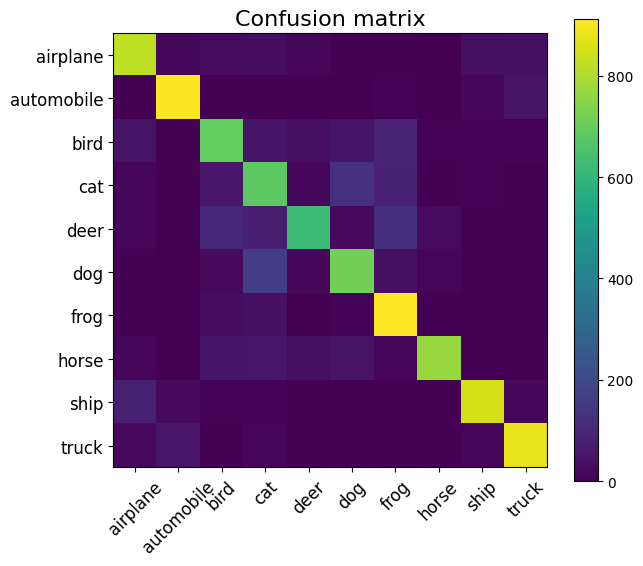

Test accuracy: 0.7859


In [43]:
# make test predictions
y_pred_test = model.predict(x_test)
y_pred_test_classes = np.argmax(y_pred_test, axis=1)
y_pred_test_max_probas = np.max(y_pred_test, axis=1)
y_test_index = [list(onehot).index(1) for onehot in y_test]

# confusion matrix and accuracy
from sklearn.metrics import confusion_matrix, accuracy_score
plt.figure(figsize=(7, 6))
plt.title('Confusion matrix', fontsize=16)
plt.imshow(confusion_matrix(y_test_index, y_pred_test_classes))
plt.xticks(np.arange(10), cifar10_classes, rotation=45, fontsize=12)
plt.yticks(np.arange(10), cifar10_classes, fontsize=12)
plt.colorbar()
plt.show()
print("Test accuracy:", accuracy_score(y_test_index, y_pred_test_classes))

Here, the test dataset is used the test the network. The model predicts class probabilities for each test image, and the predicted class is determined by selecting the class with the highest probability. A confusion matrix is generated to visualize how often the model is right for each category. Finally, the overall test accuracy is calculated.

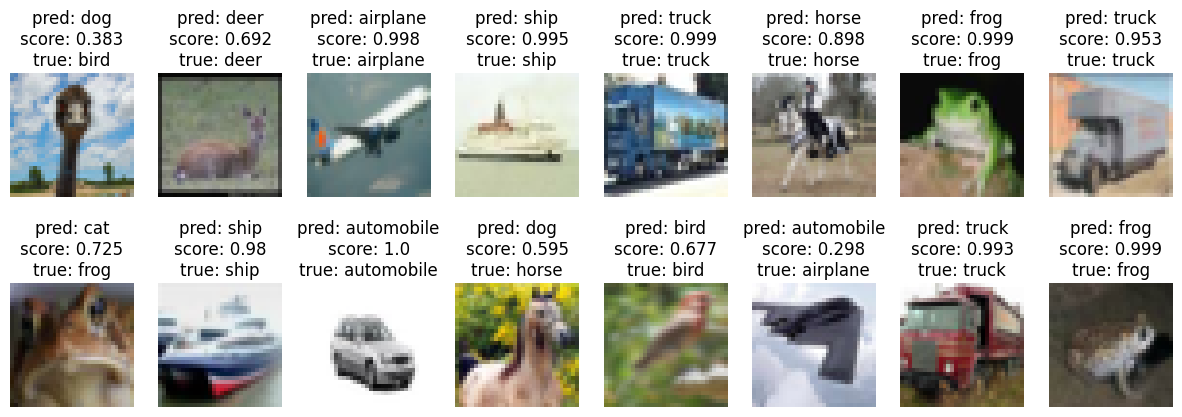

In [44]:
# inspect preditions
cols = 8
rows = 2
fig = plt.figure(figsize=(2 * cols - 1, 3 * rows - 1))
for i in range(cols):
    for j in range(rows):
        random_index = np.random.randint(0, len(y_test))
        ax = fig.add_subplot(rows, cols, i * rows + j + 1)
        ax.grid('off')
        ax.axis('off')
        ax.imshow(x_test[random_index, :])
        pred_label = cifar10_classes[y_pred_test_classes[random_index]]
        pred_proba = y_pred_test_max_probas[random_index]
        true_label = cifar10_classes[y_test_index[random_index]]
        ax.set_title("pred: {}\nscore: {:.3}\ntrue: {}".format(
               pred_label, pred_proba, true_label
        ))
plt.show()

Here, different images randomly selected are displayed from the test images. we can see the predicted label and the right one as well as the confident score of the model. this allows a visual check of how well the model performs and how many mistakes it makes.

# Some tips on how to improve:

* The ultimate quest is to create a network that has as high __accuracy__ as you can push it.

## Potential grading:
* starting at zero points
* +2 for describing your iteration path in a report below.
* +2 for building a network that gets above 20% accuracy
* +1 for beating each of these milestones on __TEST__ dataset:
    * 50% (5 total)
    * 60% (6 total)
    * 65% (7 total)
    * 70% (8 total)
    * 75% (9 total)
    * 80% (10 total)

## Bonus points
Common ways to get bonus points are:
* Get higher score, obviously.
* Anything special about your NN. For example \"A super-small/fast NN that gets 80%\" gets a bonus.
* Any detailed analysis of the results. (saliency maps, whatever)


## Tips on what can be done:

 * __Network size__
   * More neurons, 
   * More layers, ([lasagne docs](http://lasagne.readthedocs.org))
   * Nonlinearities in the hidden layers
   * tanh, relu, leaky relu, etc
   * Larger networks may take more epochs to train, so don't discard your net just because it could didn't beat the baseline in 5 epochs.

 * __Convolution layers__
   * they __are a must__ unless you have any super-ideas
   * `network = lasagne.layers.Conv2DLayer(prev_layer,`
     `                       num_filters = n_neurons,`
     `                       filter_size = (filter width, filter height),`
     `                       nonlinearity = some_nonlinearity)`
   * Warning! Training convolutional networks can take long without GPU. That's okay.
     * If you are CPU-only, we still recomment to try a simple convolutional architecture
     * a perfect option is if you can set it up to run at nighttime and check it up at the morning.
     * Make reasonable layer size estimates. A 128-neuron first convolution is likely an overkill.
     * __To reduce computation__ time by a factor in exchange for some accuracy drop, try using __stride__ parameter. A stride=2 convolution should take roughly 1/4 of the default (stride=1) one.

   * Plenty other layers and architectures
     * http://lasagne.readthedocs.org/en/latest/modules/layers.html
     * batch normalization, pooling, etc


 * __Early Stopping__
   * Training for 100 epochs regardless of anything is probably a bad idea.
   * Some networks converge over 5 epochs, others - over 500.
   * Way to go: stop when validation score is 10 iterations past maximum


 * __Faster optimization__ - 
   * rmsprop, nesterov_momentum, adam, adagrad and so on.
     * Converge faster and sometimes reach better optima
     * It might make sense to tweak learning rate/momentum, other learning parameters, batch size and number of epochs
   * __BatchNormalization__ (lasagne.layers.batch_norm) FTW!


 * __Regularize__ to prevent overfitting
   * Add some L2 weight norm to the loss function, theano will do the rest
     * Can be done manually or via - http://lasagne.readthedocs.org/en/latest/modules/regularization.html
   * Dropout - to prevent overfitting
     * `lasagne.layers.DropoutLayer(prev_layer, p=probability_to_zero_out)`   
     * Don't overdo it. Check if it actually makes your network better


 * __Data augmentation__ - getting 5x as large dataset for free is a great deal
   * Zoom-in+slice = move
   * Rotate+zoom(to remove black stripes)
   * any other perturbations
   * Add Noize (easiest: GaussianNoizeLayer)
   * Simple way to do that (if you have PIL/Image): 
     * ```from scipy.misc import imrotate,imresize```
     * and a few slicing
   * Stay realistic. There's usually no point in flipping dogs upside down as that is not the way you usually see them.


